This notebook is the second of 2 notebooks that was used to test the eBEER model code against the example systems provided in Engel et al. 2020 (https://ui.adsabs.harvard.edu/abs/2020MNRAS.497.4884E/abstract).

This notebook does so by using the system parameters given in the Engel et al. 2020 to generate light curves with PHOEBE. It must be noted that PHOEBE 2.2+ does NOT support Beaming and so this notebook will not be testing the beaming effect.

Alternatively the first notebook tests against these systems using their Kepler data. For more details refer to the first notebook, "PaperSystemsTesting1.ipynb"

We start by importing the necessary packages:
 - numpy, pandas, matplotlib
 - phoebe
 - astropy.units - used to ensure PHOEBE understand what units we are working with
 - scipy.optimize.curve_fit - for fitting
 - testing_utils - a .py file with some general tools for constructing and printing PHOEBE binaries
 - phoebe_to_eBEER - .py file containing model code to take a phoebe binary and return eBEER model light curve

In [1]:
import phoebe

import sys
sys.path.insert(1, '../scripts')
from phoebe_to_ebeer import get_ebeer_lc
from binary_parameters import BinaryParams
import testing_utils as utils

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from astropy import units as u

from scipy.optimize import curve_fit

# System Parameters

We store all the parameters for the example sysems in the paper. They independently fit for these parameters with the eBEER model and PHOEBE. We store the parameters as a list of dataframes, where each dataframe refers to one system and contains 2 columns, the eBEER and PHOEBE fit parameters. This notebook will only work with the second column.

Metallicity, Linear Limb Darkening Coefficients, and Gravity Darkening Coefficients were found using MAST data and ExoCTK calculations with Kepler as the passband and the Phoeix ACES atmosphere model (unless otherwise noted)

In [2]:
systems = ('KIC6292925', 'KIC5200778', 'KIC4931390')

KIC6292925 = {
    "Fitted Model": ['eBEER', 'PHOEBE'],
    "Porb": [13.6126, 13.6122],
    "t0_perpass": [874.04, 875.977],
    "M1": [1.9, 1.89],
    "M2": [0.50, 0.50],
    "R1": [1.8, 1.80],
    "R2": [1.3, 1.10],
    "T1": [8300, 8400],
    "T2": [6000, 7000],
    "incl": [71, 72],
    "per0": [157, 153],
    "ecc": [0.232, 0.2491],
    "metallicity": [0.087, 0.087],
    # Had to use Kurucz ATLAS9 Model as the Phoenix ACES model doesnt cover
    # Teff range
    "u1": [0.622, 0.606],
    "u2": [0.741, 0.616],
}

KIC5200778 = {
    "Fitted Model": ['eBEER', 'PHOEBE'],
    "Porb": [16.357, 16.3536],
    "t0_perpass": [806.6, 804.2],
    "M1": [1.2, 1.20],
    "M2": [0.40, 0.37],
    "R1": [2.4, 2.30],
    "R2": [0.14, 0.47],
    "T1": [6000, 6500],
    "T2": [4000, 3500],
    "incl": [23, 24],
    "per0": [-1, 2],
    "ecc": [0.35, 0.26],
    "metallicity": [None,None], # Not available in MAST table so defaulting to 0
    "u1": [0.741, 0.687],
    "u2": [0.577, 0.774],
}

KIC4931390 = {
    "Fitted Model": ['eBEER', 'PHOEBE'],
    "Porb": [7.6064, 7.6080],
    "t0_perpass": [798.44, 794.78],
    "M1": [1.20, 1.10],
    "M2": [0.10, 0.13],
    "R1": [1.48, 1.42],
    "R2": [0.7, 0.66],
    "T1": [6500, 6620],
    "T2": [5500, 6500],
    "incl": [50, 35],
    "per0": [158, 160],
    "ecc": [0.08, 0.040],
    "metallicity": [-0.313, -0.313],
    "u1": [0.695, 0.693],
    "u2": [0.736, 0.695],
}

dfs = (KIC6292925, KIC5200778, KIC4931390)

Then we define a function to construct the phoebe binary for one of the above systems.

In [3]:
def grab_fit_params(df, idx):
    cur_fit_params = df.loc[idx]
    fit_type = cur_fit_params.pop('Fitted Model')
    pb = utils.get_phoebe_binary(**cur_fit_params)
    pb.add_dataset('lc', times=phoebe.linspace(0,1,101), dataset='lc01')
    return fit_type, pb

# Select System
Here we select which system we want to work with and then construct all necessary objects for testing.

First we select a system by modifying $i$: (0 = KIC6292925, 1 = KIC5200778, 2 = KIC4931390). Then the following cell will construct a phoebe_binary_ for this system as well as a eBEERParams object which we use to quickly grab parameters like the Porb of the system as necessary. For more details on the eBEERParams object see my code in "..\scripts\phoebe_to_eBEER.py".

We want fit_type_ to be PHOEBE for this notebook.

In [4]:
i = 2
target_name = systems[i]
df = pd.DataFrame(dfs[i])
fit_type_P, phoebe_binary_P = grab_fit_params(df, 1)

# eBEERParams object to grab frequently used values like Porb and t0
binary_params = BinaryParams(from_phoebe=phoebe_binary_P) 

print(target_name, fit_type_P)
utils.print_pb_params(phoebe_binary_P)

KIC4931390 PHOEBE
Orbit - e: 0.04,  i: 35.0,  $\omega$: 160.0,  Porb: 7.608,  t0_periastron: 794.78,  q: 0.11818181818181818
Star 1 - M1: 1.1,  R1: 1.42,  T1: 6620.0,  Prot1: 7.608,  Limb Dark. Coeff: [0.693],  Grav Dark. Coeff: 0.32
Star 2 - M2: 0.13,  R2: 0.66,  T2: 6500.0,  Prot2: 7.608,  Limb Dark. Coeff: [0.695],  Grav Dark. Coeff: 0.32


# Setup PHOEBE Binary and Run LC Dataset

PHOEBE returns absolute flux so we must convert this to relative flux with the flux of the system with all effects turned off as the reference (this is the modulating eBEER calculates).

To do this we initialize the first phoebe_binary and simulate the lightcurve with the effects on.

We set passband to Kepler and use Phoenix as the atmosphere model. We can also conveniently turn of eclipses with `'eclipse_method'='only_horizon'`.

In [5]:
time_P = np.linspace(binary_params.t0, binary_params.t0 + 2*binary_params.per, 201)

phoebe_binary_P.add_dataset('lc', times= time_P, dataset='lc01', overwrite=True)
phoebe_binary_P.set_value_all('ntriangles', 25000)
phoebe_binary_P['eclipse_method'] = 'only_horizon'
phoebe_binary_P['passband'] = 'Kepler:mean'
phoebe_binary_P.set_value_all('atm', 'phoenix')
phoebe_binary_P.run_compute()

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 201/201 [31:58<00:00,  9.55s/it]


<ParameterSet: 3 parameters | qualifiers: fluxes, times, comments>

We now initialize the second binary and simulate the light curve with all effects off.

We can turn off reflection with `'irrad_method'='none'` and ellipsoidal with `'distortion_method'='sphere'`. We have to turn off ellipsoidal for both stars which can be easily accomplished with `set_value_all()`

In [6]:
_, phoebe_binary_P2 = grab_fit_params(df, 1)
phoebe_binary_P2.add_dataset('lc', times=0, dataset='lc01', overwrite=True)
phoebe_binary_P2.set_value_all('ntriangles', 25000)
phoebe_binary_P2['eclipse_method'] = 'only_horizon'
phoebe_binary_P2['passband'] = 'Kepler:mean'
phoebe_binary_P2.set_value_all('atm', 'phoenix')
phoebe_binary_P2.set_value('irrad_method', 'none')
phoebe_binary_P2.set_value_all('distortion_method', value='sphere')
phoebe_binary_P2.run_compute()

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  8.95it/s]


<ParameterSet: 3 parameters | qualifiers: fluxes, times, comments>

We then compute relative flux and conver to ppm

In [7]:
flux = phoebe_binary_P[f'fluxes@lc01@latest@model'].value
ref_flux = phoebe_binary_P2['fluxes@lc01@latest@model'].value
relative_flux_ = (flux - ref_flux)/ref_flux * 1e6

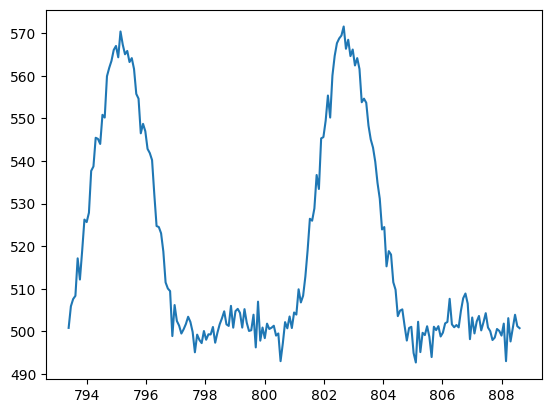

In [8]:
plt.plot(time_P, relative_flux_)

# Run Fit

The next cell contains fit_eBEER_PHOEBE which we will pass to scipy.curve_fit we have the fitting code. We scale all values to range (0,1) using fit_scaling_Kepler to improve fitting time and accuracy. Faigler & Mazeh 2011 (https://ui.adsabs.harvard.edu/abs/2011MNRAS.415.3921F/abstract) offers loose suggested ranges for the scaling coefficients. I loosen the ranges a little more as the suggested values are not hard limits, and I found this to still give satisfactory results.

In [9]:
def fit_scaling_PHOEBE(time_shift, arefl1, arefl2):
    scaled = np.zeros(3)
    scaled[0] = time_shift * binary_params.per
    scaled[1] = arefl1 * 7
    scaled[2] = arefl2 * 7
    return scaled

def fit_eBEER_PHOEBE(t, time_shift, arefl1, arefl2):
   
  scaled = fit_scaling_PHOEBE(time_shift, arefl1, arefl2)

  flux = get_ebeer_lc(phoebe_binary_P, (t + scaled[0]) % binary_params.per, 0, 0, scaled[1], scaled[2])
  
  return flux

Now we run the below cell to help us make a good initial guess for the time_shift. The resulting plot has beaming and reflection OFF.

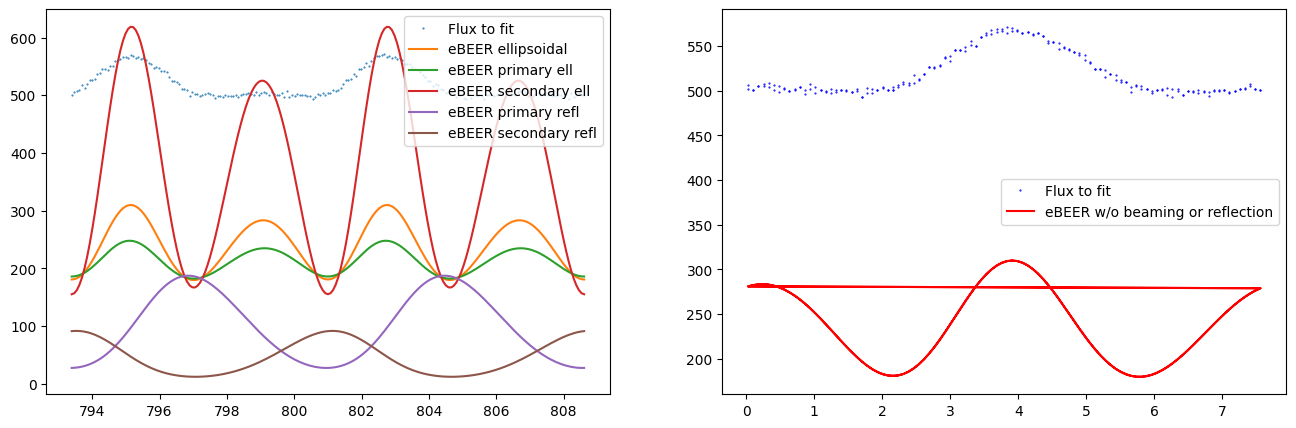

In [28]:
ellipsoidal = get_ebeer_lc(phoebe_binary_P, time_P, 0,0,0,0)
primary_ellipsoidal, secondary_ellipsoidal = get_ebeer_lc(phoebe_binary_P, time_P, 0,0,0,0, 'split')
primary_reflected, secondary_reflected = get_ebeer_lc(phoebe_binary_P, time_P, 0, 0, 0.1, 0.01, 'split', True)
phase = (time_P) % binary_params.per

plt.figure(figsize=(16,5), label= 'Gauge initial guess for time shift')
plt.subplot(121)
plt.plot(time_P, relative_flux_, '.', markersize= 1, label= 'Flux to fit')
plt.plot(time_P, ellipsoidal, '-', label= 'eBEER ellipsoidal')
plt.plot(time_P, primary_ellipsoidal, '-', label= 'eBEER primary ell')
plt.plot(time_P, secondary_ellipsoidal, '-', label= 'eBEER secondary ell')
plt.plot(time_P, primary_reflected, '-', label= 'eBEER primary refl')
plt.plot(time_P, secondary_reflected, '-', label= 'eBEER secondary refl')
plt.legend()

plt.subplot(122)
plt.plot(phase, relative_flux_, 'b.', markersize= 1, label= 'Flux to fit')
plt.plot(phase, flux, 'r', label= 'eBEER w/o beaming or reflection')
plt.legend()

Now we can run the fit and view the results

In [22]:
for time_offset in np.linspace(0, 1, 10):
    popt_P, pcov_P = curve_fit(fit_eBEER_PHOEBE, time_P, relative_flux_, 
                               p0= (time_offset, 0.1, 0.1), 
                               bounds= ([0, 0, 0], [1, 1, 1]))
    print(time_offset, pcov_P)

0.0 [[ 9.53448082e-06  2.05381681e-07 -2.19980338e-07]
 [ 2.05381681e-07  3.14343633e-08 -1.88195168e-08]
 [-2.19980338e-07 -1.88195168e-08  3.48592891e-08]]
0.1111111111111111 [[ 9.53448084e-06  2.05381683e-07 -2.19980340e-07]
 [ 2.05381683e-07  3.14343634e-08 -1.88195169e-08]
 [-2.19980340e-07 -1.88195169e-08  3.48592891e-08]]
0.2222222222222222 [[ 9.53450102e-06  2.05381898e-07 -2.19980559e-07]
 [ 2.05381898e-07  3.14343633e-08 -1.88195166e-08]
 [-2.19980559e-07 -1.88195166e-08  3.48592885e-08]]
0.3333333333333333 [[ 9.53448231e-06  2.05381722e-07 -2.19980377e-07]
 [ 2.05381722e-07  3.14343644e-08 -1.88195179e-08]
 [-2.19980377e-07 -1.88195179e-08  3.48592900e-08]]
0.4444444444444444 [[ 9.52473296e-05  2.02160846e-06 -2.19225447e-06]
 [ 2.02160846e-06  3.13414201e-07 -1.89436153e-07]
 [-2.19225447e-06 -1.89436153e-07  3.56615131e-07]]
0.5555555555555556 [[ 9.52520242e-05  2.02166716e-06 -2.19226584e-06]
 [ 2.02166716e-06  3.13415947e-07 -1.89436170e-07]
 [-2.19226584e-06 -1.89436170

In [23]:
fit_params_P = ('Time Shift', 'Alpha Reflective 1', 'Alpha Reflective 2')
rescaled_P = fit_scaling_PHOEBE(popt_P[0], popt_P[1], popt_P[2])
for name,value in zip(fit_params_P, rescaled_P):
    print(name+':', value)

Time Shift: 7.598490454581109
Alpha Reflective 1: 0.17559392072085023
Alpha Reflective 2: 0.17424402567684588


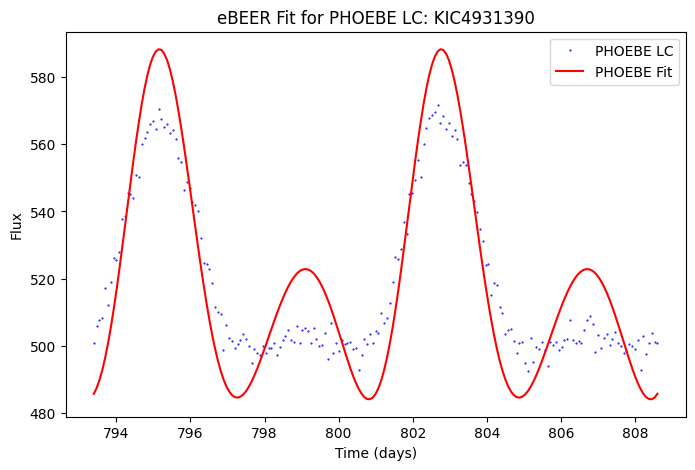

In [24]:
fit_flux_P = fit_eBEER_PHOEBE(time_P, popt_P[0], popt_P[1], popt_P[2])

plt.figure(figsize=(8, 5))
plt.plot(time_P, relative_flux_, 'b.', markersize=1, label= 'PHOEBE LC')
plt.plot(time_P, fit_flux_P, 'r', markersize=1, label= 'PHOEBE Fit')
plt.title(f'eBEER Fit for PHOEBE LC: {target_name}')
plt.xlabel('Time (days)')
plt.ylabel('Flux')
plt.legend()

In [14]:
dif = np.abs(fit_flux_P - relative_flux_)
MSD = np.sqrt(np.mean(dif**2))

print(f'Mean Diff: {np.mean(dif)} ppm   STD: {np.std(dif)} ppm')
print(f'MSD: {MSD} ppm')

Mean Diff: 12.144301836279746 ppm   STD: 5.7941676996290346 ppm
MSD: 13.45572169829965 ppm
